In [ ]:
%load_ext autoreload
%autoreload 2
from causal_comparator.data_generation import create_experiment_setup, simulate_from_graph

In [11]:
import numpy as np
import pandas as pd
import lingam

In [12]:
# 1. Configuration: High Sample Size for Perfect Estimation
n_nodes = 10
edge_prob = 0.3
n_perturbations = 3
n_samples = 10000  # 10k samples ensures the non-Gaussian signal is undeniable

print(f"🚀 Starting Recovery Test: {n_nodes} nodes, {n_samples} samples")
print("-" * 50)

# 2. Generate Ground Truth and Data
B1_true, B2_true, delta_true = create_experiment_setup(n_nodes, edge_prob, n_perturbations)
df1 = simulate_from_graph(B1_true, n_samples, seed=42)
df2 = simulate_from_graph(B2_true, n_samples, seed=43)

# 3. Individual Graph Recovery
model1 = lingam.DirectLiNGAM()
model2 = lingam.DirectLiNGAM()

model1.fit(df1)
model2.fit(df2)

B1_est = model1.adjacency_matrix_
B2_est = model2.adjacency_matrix_

# 4. Success Metrics Function
def evaluate_recovery(true_mat, est_mat, name):
    # Binary masks (using a small epsilon for numerical stability)
    t_bin = (np.abs(true_mat) > 0).astype(int)
    e_bin = (np.abs(est_mat) > 0.05).astype(int)
    
    # Structure Accuracy
    correct_elements = np.sum(t_bin == e_bin)
    acc = (correct_elements / (n_nodes**2)) * 100
    
    # Weight Error (MAE on true edges)
    mask = t_bin == 1
    mae = np.mean(np.abs(true_mat[mask] - est_mat[mask])) if np.any(mask) else 0
    
    print(f"✅ {name} Recovery:")
    print(f"   Structure Accuracy: {acc:.2f}%")
    print(f"   Weight MAE:         {mae:.4f}")
    return t_bin, e_bin

# 5. Execute Evaluation
t1, e1 = evaluate_recovery(B1_true, B1_est, "Graph 1")
t2, e2 = evaluate_recovery(B2_true, B2_est, "Graph 2")

# 6. The "Difference" Verification
# This tests if the delta between our estimates matches the true delta
true_diff = delta_true.flatten()
est_diff = (e1 != e2).astype(int).flatten()

delta_acc = (np.sum(true_diff == est_diff) / len(true_diff)) * 100
print("-" * 50)
print(f"💎 FINAL DELTA RECOVERY ACCURACY: {delta_acc:.2f}%")

🚀 Starting Recovery Test: 10 nodes, 10000 samples
--------------------------------------------------
✅ Graph 1 Recovery:
   Structure Accuracy: 100.00%
   Weight MAE:         0.0073
✅ Graph 2 Recovery:
   Structure Accuracy: 100.00%
   Weight MAE:         0.0108
--------------------------------------------------
💎 FINAL DELTA RECOVERY ACCURACY: 100.00%


In [40]:
from lingam.utils import make_dot
n_nodes = 10
n_samples = 10000
n_diffs = 4 # The number of edges in (E1 - E2)

# Generate ground truth (this deletes 4 and adds 4)
B1_true, B2_true, delta_true = create_experiment_setup(
    n_nodes=n_nodes, 
    edge_prob=0.3, 
    n_diffs=n_diffs
)

# Simulate High-Fidelity Data
#df1 = simulate_from_graph(B1_true, n_samples, seed=42)
#df2 = simulate_from_graph(B2_true, n_samples, seed=43)

# Estimation
#model1 = lingam.DirectLiNGAM()
#model2 = lingam.DirectLiNGAM()

#model1.fit(df1)
#model2.fit(df2)


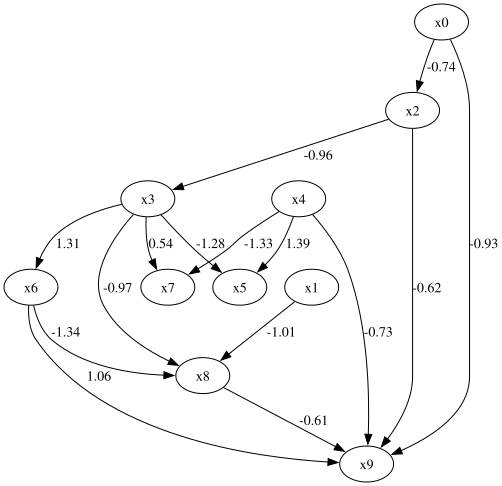

In [41]:
make_dot(B1_true)

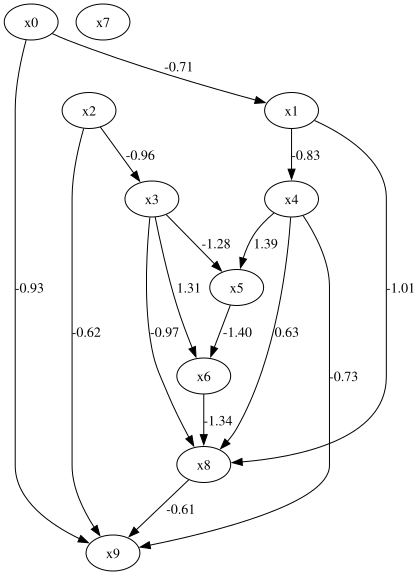

In [42]:
make_dot(B2_true)

In [37]:
from causal_comparator.data_generation import sample_lingam_weight
# Generate G1
B1 = np.zeros((n_nodes, n_nodes))
for i in range(n_nodes):
    for j in range(i):
        if np.random.rand() < edge_prob:
            B1[i, j] = sample_lingam_weight()

# Identify potential changes (strictly lower triangular for DAG)
is_lower_tri = np.tril(np.ones((n_nodes, n_nodes), dtype=bool), k=-1)

# Indices of existing edges (for deletion)
existing_edges = np.argwhere((B1 != 0) & is_lower_tri)
# Indices of non-edges (for addition)
potential_new_edges = np.argwhere((B1 == 0) & is_lower_tri)

In [38]:
existing_edges

array([[2, 0],
       [4, 1],
       [4, 2]])

In [39]:
B1

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.80964125,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        , -0.93308552,  1.24107268,  0.        ,  0.        ]])